In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Example: The standard heat of reaction as a function of temperature

**Works Illustration 8.5-2** - $\mathrm{N_2O_4} = 2\,\mathrm{NO_2}$ from 200 to 600 K -
and draws the curve behind it.

This is the shortest calculation in the chapter and it is almost entirely about *reading
the book's own appendices with code*. Two ingredients, both tabulated:

- **Appendix A.IV** gives the standard enthalpies of formation at 25 $^\circ$C, and
  Eq. 8.5-3 turns them into the heat of reaction at that one temperature:
  $$\Delta_{\text{rxn}}H^{\circ}(T) = \sum_i \nu_i\, \Delta_{\text{f}}\underline{H}_i^{\circ}(T)$$
- **Appendix A.II** gives the ideal-gas heat capacities, and Eq. 8.5-5 carries the result
  to any other temperature:
  $$\Delta_{\text{rxn}}H^{\circ}(T) = \Delta_{\text{rxn}}H^{\circ}(25^\circ\mathrm{C}) + \int_{298.15}^{T} \sum_i \nu_i\, C_{P,i}^{*}\, dT$$

Both appendices are in `code/data/react_property.csv`, so the notebook needs no numbers of
its own - only the stoichiometry.

In [2]:
import sys
sys.path.append("..")           # so `import thermo` finds code/thermo

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from thermo.data import reaction_cp, formation_enthalpy, get_reaction_species

## Stoichiometry

The whole reaction enters as a dictionary. Products positive, reactants negative - the
Chapter 2 sign convention, unchanged.

In [3]:
nu = {"NO2": 2, "N2O4": -1}          # N2O4 = 2 NO2

for name, coeff in nu.items():
    row = get_reaction_species(name)
    print(f"{name:6s}  nu = {coeff:+d}   dfH = {row['DH']:8.2f} kJ/mol   "
          f"dfG = {row['DG']:8.2f} kJ/mol")

NO2     nu = +2   dfH =    33.20 kJ/mol   dfG =    51.30 kJ/mol
N2O4    nu = -1   dfH =     9.20 kJ/mol   dfG =    97.90 kJ/mol


## The heat of reaction at 25 $^\circ$C

The reference-state enthalpies of the atomic species cancel, because atoms are conserved
in a chemical reaction - which is what makes a table of *formation* properties useful at
all. What is left is Eq. 8.5-3.

In [4]:
dHrxn_298 = sum(coeff * formation_enthalpy(name) for name, coeff in nu.items())

print(f"dHrxn(25 C) = {dHrxn_298/1e3:.2f} kJ per mol of N2O4 reacted")
print("positive, so the dissociation is endothermic")

dHrxn(25 C) = 57.20 kJ per mol of N2O4 reacted
positive, so the dissociation is endothermic


## Carrying it to other temperatures

Both species are gases in their standard states, so $C_P^{\circ} = C_P^{*}$ and the
temperature correction is an integral of the ideal-gas heat capacities weighted by the
stoichiometric coefficients. Appendix A.II writes each one as

$$C_P^{*} = a + bT + cT^2 + dT^3 \qquad \mathrm{J/(mol\,K)}$$

**Watch the scaling.** Appendix A.II prints $b$, $c$ and $d$ multiplied by $10^{2}$,
$10^{5}$ and $10^{9}$ respectively, and `react_property.csv` stores them in that printed
form. `reaction_cp` returns them already scaled, so the coefficients below can be used
directly. Reading the raw CSV columns instead is an easy way to get an answer wrong by
three orders of magnitude without any warning.

In [5]:
cp = sum(coeff * reaction_cp(name) for name, coeff in nu.items())
a, b, c, dd, e = cp

print("sum(nu_i Cp*_i) =")
print(f"  {a:8.4f} {b:+.4e} T {c:+.4e} T^2 {dd:+.4e} T^3     J/(mol K)")
print()
for T in (200, 298.15, 400, 600):
    print(f"  dCp at {T:6.2f} K = {a + b*T + c*T**2 + dd*T**3 + e/T**2:7.2f} J/(mol K)")

sum(nu_i Cp*_i) =
   12.8040 -7.2390e-02 T +4.3010e-05 T^2 +1.5732e-08 T^3     J/(mol K)

  dCp at 200.00 K =    0.17 J/(mol K)
  dCp at 298.15 K =   -4.54 J/(mol K)
  dCp at 400.00 K =   -8.26 J/(mol K)
  dCp at 600.00 K =  -11.75 J/(mol K)


$\sum_i \nu_i C_{P,i}^{*}$ is small and changes sign inside the range - near zero at
200 K, about $-4.5$ J/(mol K) at room temperature, $-11.8$ J/(mol K) at 600 K. So the heat
of reaction will be nearly flat at the cold end and fall away at the hot end, and the whole
temperature correction will be small compared with the 57 kJ/mol it corrects.

In [6]:
def dHrxn(T, T0=298.15):
    """Standard heat of reaction at T, J per mol N2O4 (Eq. 8.5-5)."""
    T = np.asarray(T, dtype=float)
    integral = (a * (T - T0)
                + b / 2 * (T**2 - T0**2)
                + c / 3 * (T**3 - T0**3)
                + dd / 4 * (T**4 - T0**4)
                - e * (1 / T - 1 / T0))
    return dHrxn_298 + integral


Tk = np.array([200, 300, 400, 500, 600])
print(pd.DataFrame({"T (K)": Tk,
                    "dHrxn (kJ/mol N2O4)": np.round(dHrxn(Tk) / 1e3, 3)}
                   ).to_string(index=False))

 T (K)  dHrxn (kJ/mol N2O4)
   200               57.423
   300               57.192
   400               56.538
   500               55.580
   600               54.448


## The figure

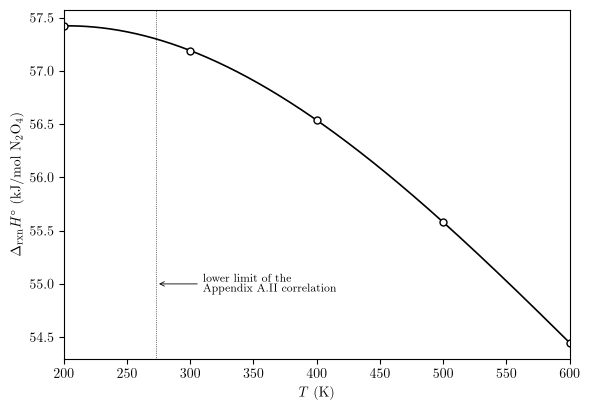

In [7]:
fig, ax = plt.subplots(figsize=(6.0, 4.2))

Ts = np.linspace(200, 600, 400)
ax.plot(Ts, dHrxn(Ts) / 1e3, "-", color="black", lw=1.2)
ax.plot(Tk, dHrxn(Tk) / 1e3, "o", mfc="white", mec="black", ms=5, lw=0)

ax.set_xlabel(r"$T$ (K)")
ax.set_ylabel(r"$\Delta_{\mathrm{rxn}}H^{\circ}$ (kJ/mol $\mathrm{N_2O_4}$)")
ax.set_xlim(200, 600)
ax.axvline(273.15, color="black", lw=0.5, ls=":")
ax.annotate("lower limit of the\nAppendix A.II correlation",
            xy=(273.15, 55.0), xytext=(310, 55.0), fontsize=8, va="center",
            arrowprops=dict(arrowstyle="->", lw=0.6))

fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/c08uf002.pdf")
plt.show()

## Two things this curve is hiding

**The heat capacities are extrapolated below 273 K.** The Appendix A.II correlations are
fitted over 273-1800 K, and this illustration asks for 200 K. That is not a formality: of
the 223 J/mol by which $\Delta_{\text{rxn}}H^{\circ}$ at 200 K differs from its value at
25 $^\circ$C, **more than half is accumulated below the bottom of the fitted range.**

In [8]:
def integral(T, T0=298.15):
    return dHrxn(T) - dHrxn(T0)

total = integral(200.0)
inside = integral(273.15)
print(f"dHrxn(200 K) - dHrxn(298.15 K) = {total:7.1f} J/mol")
print(f"  accumulated 298.15 -> 273.15 K (inside the fit)  = {inside:7.1f} J/mol")
print(f"  accumulated 273.15 -> 200 K    (extrapolated)    = {total - inside:7.1f} J/mol"
      f"   [{100*abs(total-inside)/abs(total):.0f}% of the correction]")

dHrxn(200 K) - dHrxn(298.15 K) =   222.9 J/mol
  accumulated 298.15 -> 273.15 K (inside the fit)  =    99.9 J/mol
  accumulated 273.15 -> 200 K    (extrapolated)    =   123.0 J/mol   [55% of the correction]


It is still a small number - 123 J/mol against 57 000 - and it is a *difference* of two
extrapolations, so the errors partly cancel. But "partly" is doing real work in that
sentence, and nothing in the calculation announces that a correlation is being used outside
its range. That is the failure mode to watch for: the arithmetic never complains.

**At 200 K the standard state is hypothetical.** Dinitrogen tetroxide melts at about 262 K
and boils at about 294 K, so over most of the left half of this plot the real substance is
a liquid or a solid. The standard state is defined as the *ideal gas* at 1 bar whatever the
substance is actually doing, so the calculation is perfectly well posed - but
$\Delta_{\text{rxn}}H^{\circ}(200\ \mathrm{K})$ is not the heat you would measure in a
flask at 200 K. Sec. 9.8 is where the book takes that distinction seriously.

In [9]:
os.makedirs("output", exist_ok=True)

grid = np.arange(200, 601, 25)
out = pd.DataFrame({"T_K": grid, "dHrxn_kJ_per_mol_N2O4": np.round(dHrxn(grid) / 1e3, 4)})
out.to_csv("output/Illustration_8.5-2.csv", index=False)

with open("output/Illustration_8.5-2.txt", "w") as fh:
    fh.write("Illustration 8.5-2  Standard heat of reaction for N2O4 = 2 NO2\n")
    fh.write("Formation enthalpies from Appendix A.IV; ideal-gas heat capacities from\n")
    fh.write("Appendix A.II (correlations fitted over 273-1800 K; values below 273 K\n")
    fh.write("are extrapolated).\n\n")
    fh.write(f"dHrxn(25 C) = {dHrxn_298/1e3:.2f} kJ/mol N2O4\n\n")
    fh.write(out.to_string(index=False))
    fh.write("\n")

print("wrote output/Illustration_8.5-2.csv and output/Illustration_8.5-2.txt")

wrote output/Illustration_8.5-2.csv and output/Illustration_8.5-2.txt


## Your turn

1. **Change the reaction, not the code.** Nothing above is specific to
   $\mathrm{N_2O_4} = 2\,\mathrm{NO_2}$ except the `nu` dictionary. Compute
   $\Delta_{\text{rxn}}H^{\circ}(T)$ for the ammonia synthesis
   $\mathrm{N_2} + 3\,\mathrm{H_2} = 2\,\mathrm{NH_3}$ over 300-800 K. Is it endothermic or
   exothermic, and does the magnitude grow or shrink with temperature?

2. **Find where the correction stops being negligible.** For this reaction the temperature
   correction never exceeds about 5% of $\Delta_{\text{rxn}}H^{\circ}(25^\circ\mathrm{C})$.
   Find a reaction in `react_property.csv` for which it exceeds 20% somewhere between 300
   and 1000 K. What is different about $\sum_i \nu_i C_{P,i}^{*}$ for that reaction?

3. **Do the Gibbs energy too.** `formation_gibbs` is sitting right next to
   `formation_enthalpy`. Compute $\Delta_{\text{rxn}}G^{\circ}(25^\circ\mathrm{C})$ and
   convince yourself it is *not* obtained by the same integral - what is missing, and which
   chapter supplies it?

4. **Test the extrapolation.** Look up $C_P^{*}$ for $\mathrm{NO_2}$ at 200 K in the NIST
   Chemistry WebBook and compare it with what the Appendix A.II correlation gives there. How
   much does the disagreement move $\Delta_{\text{rxn}}H^{\circ}(200\ \mathrm{K})$? Was the
   cancellation argument above optimistic or pessimistic?